# Stage 2: Cross-State Difference-in-Differences (CA vs AZ)

**Project:** Does Daylight Saving Time Reduce Property Crime? 
**Course:** IDS 701 — Problem Solving with Data Science, Duke University, Spring 2026

**Design:** California (treated, observes DST) vs Arizona (control, never observes DST).  
**Outcomes:** Burglary and Motor Vehicle Theft (daily county-level rates per 100k residents).  
**Period:** 2022–2024.

**AZ control group:** 11 counties. Apache, Navajo, Coconino, and Graham counties are absent from the NIBRS crime data and do not appear in the panel. An exclusion guard for the three Navajo Nation counties (Apache, Navajo, Coconino) is retained in the code as a precaution. Two multi-county or unspecified entries ("MARICOPA, PINAL", "NOT SPECIFIED") are dropped at the population merge.

---

### Notebook structure

| Section | Content |
|---|---|
| 0 | Setup and data loading |
| 1 | Build model panel |
| 2 | Parallel trends check (pre-requisite) |
| 3 | Main TWFE DiD |
| 4 | Narrow-window check (±15 days around spring-forward) |
| 5 | Event study |
| 6 | Robustness checks |
| 7 | Summary |


## Section 0 — Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import os
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm

# Robustly find project root
_root = Path.cwd()
for _ in range(4):
    if (_root / "data").exists() and (_root / "scripts").exists():
        break
    _root = _root.parent
os.chdir(_root)

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

# Paths
CRIME_PATH = Path("data/processed/crime/focus_states_daily_county_counts.csv")
POP_PATH = Path(
    "data/processed/population/focus_states_county_population_2020_2024_long.csv"
)
ACS_PATH = Path(
    "data/processed/socioeconomic/acs_county_controls_derived_2021_2024.csv"
)

# Constants
STATES = ["CA", "AZ"]
CRIMES = ["burglary", "motor_vehicle_theft"]
CRIME_LABELS = {"burglary": "Burglary", "motor_vehicle_theft": "Motor Vehicle Theft"}
STATE_COLORS = {"CA": "#1f77b4", "AZ": "#e377c2"}

# AZ counties to exclude (Navajo Nation — observe DST)
AZ_EXCLUDE = {"APACHE", "NAVAJO", "COCONINO"}


# DST spring-forward dates (second Sunday in March)
def spring_forward(year: int) -> date:
    d0 = date(year, 3, 1)
    to_sun = (6 - d0.weekday()) % 7
    return d0 + timedelta(days=to_sun) + timedelta(days=7)


# DST fall-back dates (first Sunday in November)
def fall_back(year: int) -> date:
    d0 = date(year, 11, 1)
    to_sun = (6 - d0.weekday()) % 7
    return d0 + timedelta(days=to_sun)


DST_DATES = {
    y: {"start": spring_forward(y), "end": fall_back(y)} for y in [2022, 2023, 2024]
}

print("Working dir:", Path.cwd())
print("DST dates:")
for y, d in DST_DATES.items():
    print(f"  {y}: start={d['start']}  end={d['end']}")
print("\nFiles exist:")
for p in [CRIME_PATH, POP_PATH, ACS_PATH]:
    print(f"  {p.name}: {p.exists()}")

Working dir: /Users/sebinescaria/Downloads/UDS_project/Final_project/IDS701_UDS_Final_Project
DST dates:
  2022: start=2022-03-13  end=2022-11-06
  2023: start=2023-03-12  end=2023-11-05
  2024: start=2024-03-10  end=2024-11-03

Files exist:
  focus_states_daily_county_counts.csv: True
  focus_states_county_population_2020_2024_long.csv: True
  acs_county_controls_derived_2021_2024.csv: True


## Section 1 — Build Model Panel

Merge daily crime counts with population and ACS socioeconomic controls. Construct DST indicators and crime rates.

**Treatment variable:** `in_dst_window` = 1 for CA counties during the DST calendar window (spring-forward through fall-back), 0 for AZ counties year-round.

**Outcome:** `crime_rate_per_100k` = daily incidents / county population × 100,000.

**Note on AZ coverage:** The crime data contains 13 AZ county entries. Apache, Navajo, Coconino (Navajo Nation), and Graham are absent from the source data. Two entries ("MARICOPA, PINAL" and "NOT SPECIFIED") fail to match the population file and are dropped at merge, leaving **11 usable AZ counties**.

In [2]:
# ── Load raw files ─────────────────────────────────────────────────────────
crime = pd.read_csv(CRIME_PATH, parse_dates=["incident_date"])
pop = pd.read_csv(POP_PATH)
acs = pd.read_csv(ACS_PATH)

# ── Filter to CA and AZ, target crimes, years 2022-2024 ───────────────────
crime = crime[
    crime["state"].isin(STATES)
    & crime["crime_type"].isin(CRIMES)
    & (crime["incident_date"].dt.year.between(2022, 2024))
].copy()

# Normalise county names to upper for matching
crime["county_name"] = crime["county_name"].str.upper().str.strip()

# ── Exclude Navajo Nation AZ counties ─────────────────────────────────────
az_navajo_mask = (crime["state"] == "AZ") & (crime["county_name"].isin(AZ_EXCLUDE))
crime = crime[~az_navajo_mask].copy()
print(f"Rows after filtering: {len(crime):,}")
print(f"States: {sorted(crime['state'].unique())}")
print(f"Crime types: {sorted(crime['crime_type'].unique())}")
print(f"Years: {sorted(crime['incident_date'].dt.year.unique())}")

Rows after filtering: 80,559
States: ['AZ', 'CA']
Crime types: ['burglary', 'motor_vehicle_theft']
Years: [np.int32(2022), np.int32(2023), np.int32(2024)]


In [3]:
# ── Build population lookup (state × county × year) ───────────────────────
pop["data_year"] = pop["data_year"].astype(int)
pop["county_name"] = pop["county_name"].str.upper().str.strip()
pop["population"] = pd.to_numeric(pop["population"], errors="coerce")

# Exclude Navajo AZ counties from population too
pop_az_excl = (pop["state"] == "AZ") & (pop["county_name"].isin(AZ_EXCLUDE))
pop = pop[~pop_az_excl & pop["state"].isin(STATES)].copy()

pop_lookup = pop[["state", "county_name", "data_year", "population"]]

# ── Build ACS lookup (state × county × year) ──────────────────────────────
acs["data_year"] = acs["data_year"].astype(int)
# ACS has " COUNTY" suffix (e.g. "LOS ANGELES COUNTY") — strip it to match crime data
acs["county_name"] = (
    acs["county_name"].str.upper().str.strip().str.replace(" COUNTY", "", regex=False)
)
ACS_COLS = [
    "state",
    "county_name",
    "data_year",
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "bachelors_plus_rate",
]
acs_cols_present = [c for c in ACS_COLS if c in acs.columns]
acs_lookup = acs[acs["state"].isin(STATES)][acs_cols_present].copy()
for col in [
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "bachelors_plus_rate",
]:
    if col in acs_lookup.columns:
        acs_lookup[col] = pd.to_numeric(acs_lookup[col], errors="coerce")
        # Replace Census sentinel -666666666 with NaN
        acs_lookup[col] = acs_lookup[col].where(acs_lookup[col] > -999999)

print("Population lookup shape:", pop_lookup.shape)
print("ACS lookup shape:", acs_lookup.shape)

Population lookup shape: (350, 4)
ACS lookup shape: (292, 7)


In [4]:
# ── Add time variables ─────────────────────────────────────────────────────
crime["year"] = crime["incident_date"].dt.year
crime["month"] = crime["incident_date"].dt.month
crime["day_of_week"] = crime["incident_date"].dt.dayofweek  # 0=Mon, 6=Sun
crime["is_weekend"] = crime["day_of_week"].isin([5, 6]).astype(int)
crime["year_month"] = crime["incident_date"].dt.to_period("M").astype(str)

# Federal holidays (approximate — major ones that affect crime reporting)
HOLIDAYS = {
    pd.Timestamp(d)
    for y in [2022, 2023, 2024]
    for d in [f"{y}-01-01", f"{y}-07-04", f"{y}-11-11", f"{y}-12-25", f"{y}-12-31"]
}
crime["is_holiday"] = crime["incident_date"].isin(HOLIDAYS).astype(int)


# ── DST window indicator ───────────────────────────────────────────────────
# For CA: 1 during DST window; for AZ: always 0 (never observes DST)
def in_dst(row):
    if row["state"] == "AZ":
        return 0
    y = row["year"]
    d = row["incident_date"].date()
    return int(DST_DATES[y]["start"] <= d < DST_DATES[y]["end"])


crime["in_dst_window"] = crime.apply(in_dst, axis=1)


# Days relative to spring-forward (for event study and narrow window)
def days_from_spring(row):
    y = row["year"]
    return (row["incident_date"].date() - DST_DATES[y]["start"]).days


crime["days_from_dst_start"] = crime.apply(days_from_spring, axis=1)

print("DST window coverage:")
print(crime.groupby(["state", "year"])["in_dst_window"].mean().round(3))

DST window coverage:
state  year
AZ     2022    0.000
       2023    0.000
       2024    0.000
CA     2022    0.665
       2023    0.654
       2024    0.649
Name: in_dst_window, dtype: float64


In [5]:
# ── Merge population ───────────────────────────────────────────────────────
panel = crime.merge(
    pop_lookup,
    left_on=["state", "county_name", "year"],
    right_on=["state", "county_name", "data_year"],
    how="left",
)

# ── Merge ACS ─────────────────────────────────────────────────────────────
panel = panel.merge(
    acs_lookup,
    left_on=["state", "county_name", "year"],
    right_on=["state", "county_name", "data_year"],
    how="left",
    suffixes=("", "_acs"),
)

# ── Crime rate per 100k ───────────────────────────────────────────────────
panel["crime_rate_per_100k"] = panel["incident_count"] / panel["population"] * 100_000
panel["log_rate"] = np.log1p(panel["crime_rate_per_100k"])

# ── Drop rows missing population (can't compute rate) ─────────────────────
missing_pop = panel["population"].isna().sum()
panel = panel.dropna(subset=["population"]).copy()

print(f"Panel shape: {panel.shape}")
print(f"Rows dropped (missing population): {missing_pop}")
print(f"\nCounties per state:")
print(panel.groupby("state")["county_name"].nunique())
print(f"\nMissing values:")
print(
    panel[["crime_rate_per_100k", "median_household_income", "poverty_rate"]]
    .isna()
    .sum()
)

Panel shape: (79486, 22)
Rows dropped (missing population): 1073

Counties per state:
state
AZ    11
CA    58
Name: county_name, dtype: int64

Missing values:
crime_rate_per_100k        0
median_household_income    0
poverty_rate               0
dtype: int64


## Section 2 — Parallel Trends Check

The key identifying assumption of DiD is **parallel trends**: in the absence of DST, CA and AZ crime rates would have evolved similarly. We check this two ways:

1. **Visual:** Monthly average crime rates for CA vs AZ, by year. Pre-DST months (Jan–Feb) should track closely.
2. **Formal event study:** Week-by-week DiD coefficients. Pre-period coefficients (weeks < 0) should be statistically indistinguishable from zero.

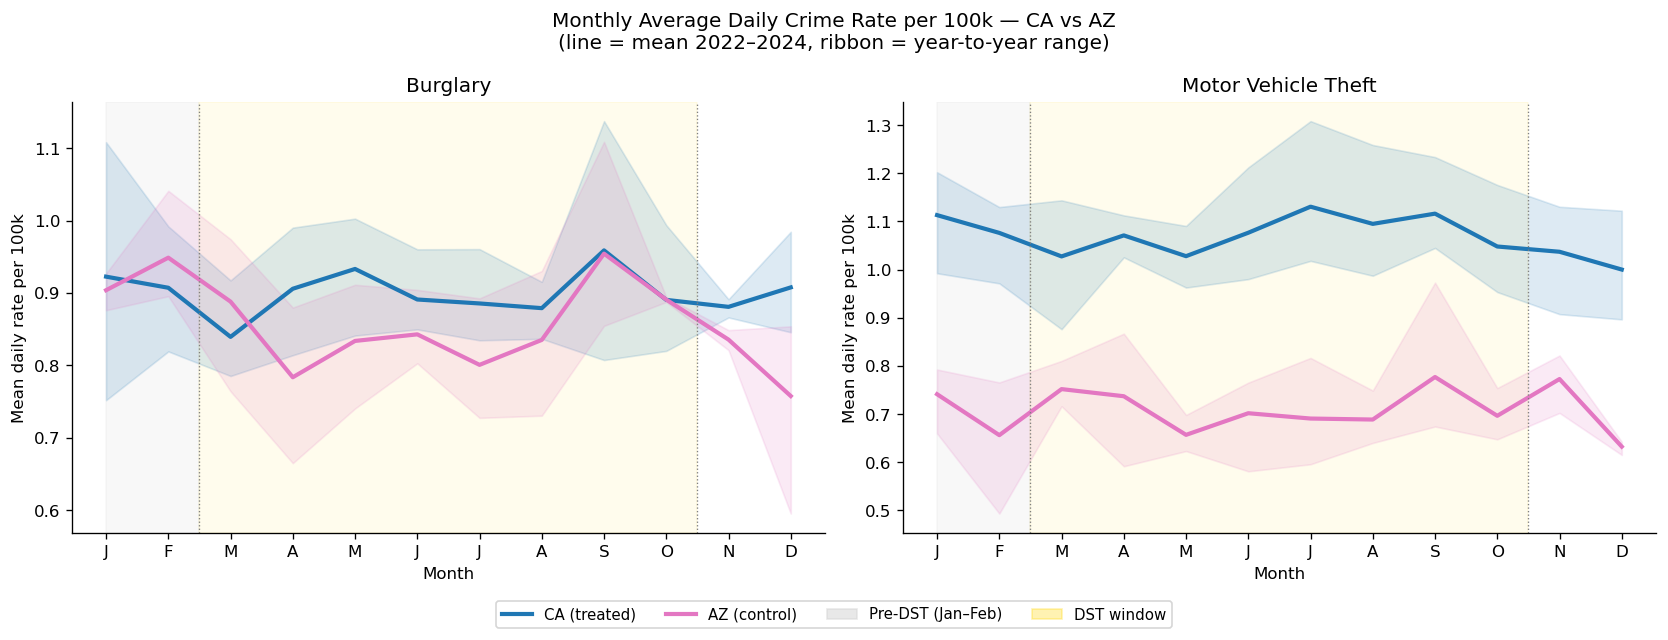


Interpretation: lines should track closely in the gray pre-DST band (Jan–Feb).
Divergence only after March supports the parallel trends assumption.


In [6]:
# ── 2.1 Visual parallel trends ────────────────────────────────────────────
# Step 1: monthly mean per state/year/month/crime_type
monthly_by_year = panel.groupby(
    ["state", "year", "month", "crime_type"], as_index=False
).agg(mean_rate=("crime_rate_per_100k", "mean"))

# Step 2: collapse across years → mean line + min/max ribbon
monthly = monthly_by_year.groupby(["state", "month", "crime_type"], as_index=False).agg(
    avg_rate=("mean_rate", "mean"),
    lo_rate=("mean_rate", "min"),
    hi_rate=("mean_rate", "max"),
)

MONTH_LABELS = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Monthly Average Daily Crime Rate per 100k — CA vs AZ\n"
    "(line = mean 2022–2024, ribbon = year-to-year range)",
    fontsize=12,
)

for ax, crime_type in zip(axes, CRIMES):
    sub = monthly[monthly["crime_type"] == crime_type]

    # Highlight pre-DST validation window (Jan–Feb)
    ax.axvspan(1, 2.5, alpha=0.15, color="lightgray", zorder=0)
    # DST window (Mar–Oct for CA)
    ax.axvspan(2.5, 10.5, alpha=0.07, color="gold", zorder=0)

    for state in STATES:
        s = sub[sub["state"] == state].sort_values("month")
        ax.plot(s["month"], s["avg_rate"], color=STATE_COLORS[state], lw=2.5)
        ax.fill_between(
            s["month"],
            s["lo_rate"],
            s["hi_rate"],
            color=STATE_COLORS[state],
            alpha=0.15,
        )

    ax.axvline(2.5, color="gray", ls=":", lw=0.8)
    ax.axvline(10.5, color="gray", ls=":", lw=0.8)
    ax.set_title(CRIME_LABELS[crime_type])
    ax.set_xlabel("Month")
    ax.set_ylabel("Mean daily rate per 100k")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_LABELS)

handles = [
    plt.Line2D([0], [0], color=STATE_COLORS["CA"], lw=2.5, label="CA (treated)"),
    plt.Line2D([0], [0], color=STATE_COLORS["AZ"], lw=2.5, label="AZ (control)"),
    plt.matplotlib.patches.Patch(
        color="lightgray", alpha=0.5, label="Pre-DST (Jan–Feb)"
    ),
    plt.matplotlib.patches.Patch(color="gold", alpha=0.3, label="DST window"),
]
fig.legend(
    handles=handles, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.06)
)
plt.tight_layout()
plt.show()

print(
    "\nInterpretation: lines should track closely in the gray pre-DST band (Jan–Feb)."
)
print("Divergence only after March supports the parallel trends assumption.")

## Section 3 — Main TWFE DiD

**Specification:**

$$\text{rate}_{ct} = \beta \cdot \text{InDSTWindow}_{ct} + \gamma \cdot \text{Controls}_{ct} + \alpha_c + \lambda_{ym} + \varepsilon_{ct}$$

where $\alpha_c$ are county fixed effects and $\lambda_{ym}$ are year-month fixed effects. Standard errors are clustered at the county level.

We run four specifications:
- **M1 Baseline:** `in_dst_window + is_weekend + is_holiday + county FE + year-month FE`
- **M2 + Socio:** M1 + socioeconomic controls
- **M3 Log rate:** M1 with log(rate) as outcome
- **M4 Year FE:** M1 but with year FE instead of year-month FE (coarser time structure)

In [7]:
def run_twfe(
    df,
    outcome,
    regressors,
    entity="county_name",
    time="year_month",
    cluster="county_name",
):
    """
    Two-way fixed effects OLS via sequential within-transformation (FWL theorem).
    County FE absorbed first, then time FE. SEs clustered at county level.
    """
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d = df[cols].dropna(subset=[outcome] + regressors).copy()
    for c in [outcome] + regressors:
        d[c] = d[c].astype(float)

    # Remove county (entity) FE
    e_means = d.groupby(entity)[[outcome] + regressors].transform("mean")
    d[[outcome] + regressors] = d[[outcome] + regressors] - e_means

    # Remove time FE
    t_means = d.groupby(time)[[outcome] + regressors].transform("mean")
    d[[outcome] + regressors] = d[[outcome] + regressors] - t_means

    X = sm.add_constant(d[regressors])
    groups = df.loc[d.index, cluster].values
    return sm.OLS(d[outcome], X).fit(cov_type="cluster", cov_kwds={"groups": groups})


def results_table(results_dict, treatment_var="in_dst_window"):
    """Format a summary table from a dict of label -> statsmodels result."""
    rows = []
    for label, res in results_dict.items():
        coef = res.params.get(treatment_var, float("nan"))
        se = res.bse.get(treatment_var, float("nan"))
        pval = res.pvalues.get(treatment_var, float("nan"))
        stars = (
            "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
        )
        ci_lo, ci_hi = coef - 1.96 * se, coef + 1.96 * se
        rows.append(
            {
                "Specification": label,
                "beta": round(coef, 5),
                "SE": f"({round(se, 5)})",
                "sig": stars,
                "p-value": round(pval, 4),
                "95% CI": f"[{ci_lo:.4f}, {ci_hi:.4f}]",
                "N": int(res.nobs),
            }
        )
    return pd.DataFrame(rows)


print("TWFE functions defined.")

TWFE functions defined.


In [8]:
# ── Run all specifications ─────────────────────────────────────────────────
BASE_CONTROLS = ["in_dst_window", "is_weekend", "is_holiday"]
SOCIO_CONTROLS = BASE_CONTROLS + [
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "bachelors_plus_rate",
]

results = {}

for ct in CRIMES:
    sub = panel[panel["crime_type"] == ct].copy()

    results[f"{ct} | M1 Baseline"] = run_twfe(sub, "crime_rate_per_100k", BASE_CONTROLS)
    results[f"{ct} | M2 + Socio"] = run_twfe(sub, "crime_rate_per_100k", SOCIO_CONTROLS)
    results[f"{ct} | M3 Log rate"] = run_twfe(sub, "log_rate", BASE_CONTROLS)
    results[f"{ct} | M4 Year FE"] = run_twfe(
        sub, "crime_rate_per_100k", BASE_CONTROLS, time="year"
    )

tbl = results_table(results)
print("=== MAIN TWFE RESULTS ===")
print(tbl.to_string(index=False))
print("\nFE: county + year-month (M1-M3), county + year (M4)")
print("SE clustered at county level. *** p<0.01, ** p<0.05, * p<0.1")

=== MAIN TWFE RESULTS ===
                    Specification     beta        SE sig  p-value            95% CI     N
           burglary | M1 Baseline -0.02470 (0.02452)       0.3136 [-0.0728, 0.0234] 39215
            burglary | M2 + Socio -0.01057 (0.01473)       0.4729 [-0.0394, 0.0183] 39215
           burglary | M3 Log rate -0.01462 (0.01049)       0.1636 [-0.0352, 0.0059] 39215
            burglary | M4 Year FE -0.01005 (0.00958)       0.2941 [-0.0288, 0.0087] 39215
motor_vehicle_theft | M1 Baseline -0.01076 (0.02232)       0.6298 [-0.0545, 0.0330] 40271
 motor_vehicle_theft | M2 + Socio  0.00199 (0.01317)       0.8801 [-0.0238, 0.0278] 40271
motor_vehicle_theft | M3 Log rate -0.00402  (0.0102)       0.6936 [-0.0240, 0.0160] 40271
 motor_vehicle_theft | M4 Year FE  0.01835  (0.0138)       0.1837 [-0.0087, 0.0454] 40271

FE: county + year-month (M1-M3), county + year (M4)
SE clustered at county level. *** p<0.01, ** p<0.05, * p<0.1


### TWFE Results

Table 1 reports the two-way fixed effects estimates of the effect of the DST window on daily property crime rates across four specifications. For burglary, all coefficients are negative, ranging from -0.025 (M1 Baseline) to -0.010 (M4 Year FE), suggesting a modest reduction in crime during the DST window relative to Arizona. However, none of these estimates are statistically significant at conventional levels (all p > 0.16). For motor vehicle theft, the coefficients are inconsistent in sign — negative under M1 and M3, near-zero under M2, and positive under M4 — with p-values ranging from 0.18 to 0.88. The lack of a consistent direction for motor vehicle theft further undermines any causal interpretation.

These results are robust to the inclusion of socioeconomic controls (M2), a log transformation of the outcome (M3), and a coarser year fixed effect structure (M4). In all cases, the 95% confidence intervals include zero.

**Figure X** visualises these estimates as a coefficient plot. All bars — blue for burglary and orange for motor vehicle theft — straddle the zero line, confirming the null result across all specifications. The wide confidence intervals, particularly for M1, reflect the limited precision of the cross-state comparison given the relatively small number of AZ counties (n=11) available as the control group.

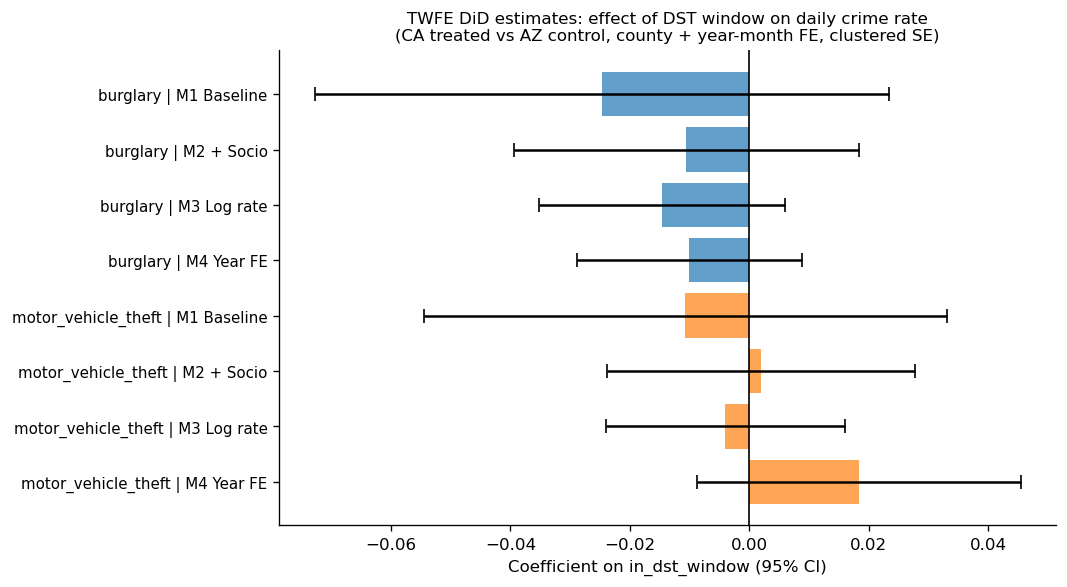

In [9]:
# ── Coefficient plot ───────────────────────────────────────────────────────
labels, coefs, ses = [], [], []
for key, res in results.items():
    labels.append(key)
    coefs.append(res.params.get("in_dst_window", np.nan))
    ses.append(res.bse.get("in_dst_window", np.nan))

coefs = np.array(coefs)
ci95 = 1.96 * np.array(ses)

# Color by crime type block
n_specs = len(CRIMES) * 4
colors_bar = [STATE_COLORS["CA"] if i < 4 else "#ff7f0e" for i in range(n_specs)]

fig, ax = plt.subplots(figsize=(9, max(5, 0.4 * len(labels))))
y_pos = np.arange(len(labels))[::-1]

ax.barh(
    y_pos,
    coefs,
    xerr=ci95,
    color=colors_bar,
    alpha=0.7,
    error_kw={"elinewidth": 1.5, "capsize": 4},
)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Coefficient on in_dst_window (95% CI)")
ax.set_title(
    "TWFE DiD estimates: effect of DST window on daily crime rate\n"
    "(CA treated vs AZ control, county + year-month FE, clustered SE)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

### Coefficient Plot

The above figure presents the TWFE estimates visually as a coefficient plot. Each bar represents the estimated effect of the DST window on the daily crime rate per 100k, with horizontal lines showing the 95% confidence interval. Blue bars correspond to burglary and orange bars to motor vehicle theft.

All eight bars straddle the zero line, confirming the null result across every specification. For burglary, the bars consistently point left (negative), indicating a small downward association with DST, but the confidence intervals are wide enough to include zero in all cases. For motor vehicle theft, bars point in different directions depending on the specification — left for M1 and M3, near zero for M2, and right for M4 — reinforcing that there is no consistent or meaningful effect.

The especially wide confidence intervals for M1 (burglary and motor vehicle theft) reflect the limited number of control counties in Arizona (n=11), which constrains the precision of the cross-state comparison.

## Section 3.5 — Hourly Mechanism Test

The proposal's core hypothesis is that DST deters crime through the **daylight mechanism**: 
extending evening light reduces criminal opportunity during the 5–9 PM window when burglary 
peaks. If this mechanism is real, DST should shift *when* crime happens, not just how much.

Using hourly NIBRS data (2022-2024, ±28 days around the March 10 spring-forward), we compare 
crime across four time-of-day buckets in CA vs AZ before and after the clock change:

| Bucket | Hours | Expected effect |
|---|---|---|
| Morning dark | 5–8h | These hours become darker after spring-forward — crime may rise |
| Daytime | 9–17h | Unaffected by DST — should show no change |
| Evening light | 18–21h | These hours gain ambient light — crime may fall |
| Late night | 22–4h | Unaffected by DST — should show no change |

If the daylight mechanism is real, CA should show a drop in the evening light bucket and 
a rise in the morning dark bucket after spring-forward. AZ, which never changes its clocks, 
should show no such pattern. This is averaged across three spring-forward events (2022, 2023, 2024) and is a mechanism diagnostic rather than a primary causal estimate.

Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
States: ['AZ', 'CA']
Rows: 53,489


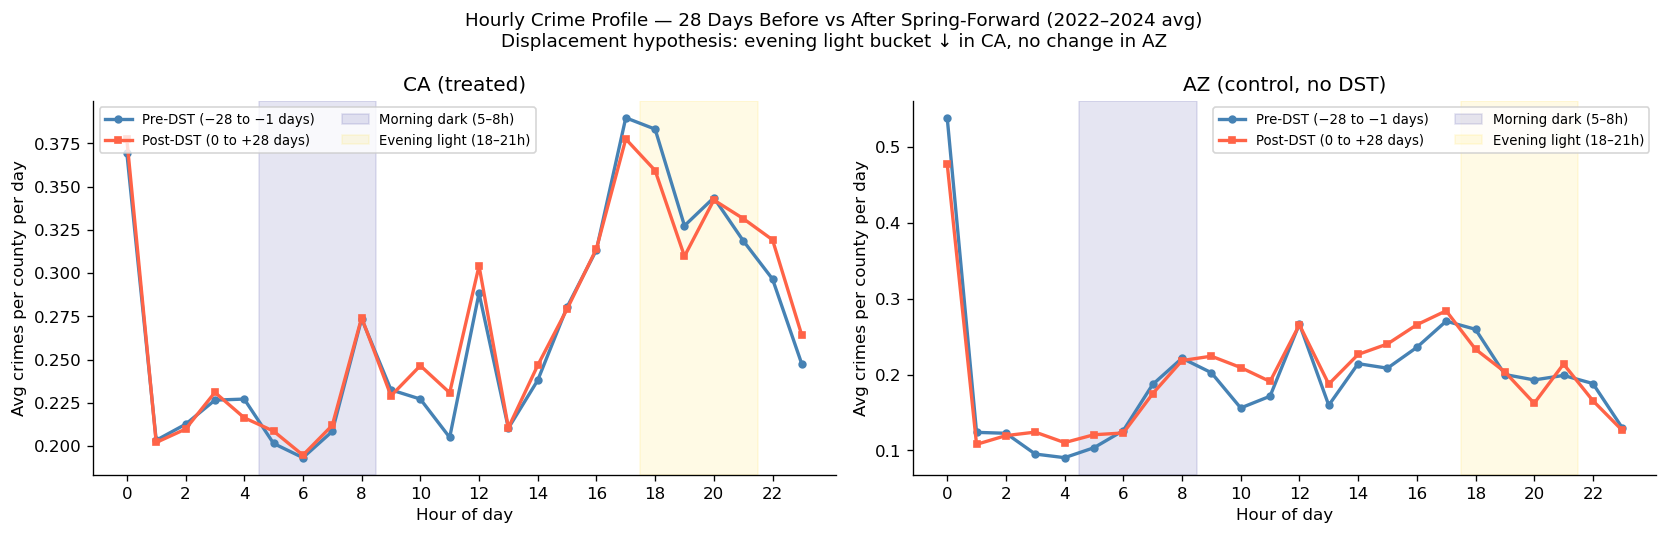


Bucket summary — CA (treated):
post_dst        pre_avg  post_avg  pct_change
time_bucket                                  
morning_dark   0.877053  0.889814         1.5
daytime        2.385263  2.438962         2.3
evening_light  1.372947  1.342846        -2.2
late_night     1.783251  1.820055         2.1

Bucket summary — AZ (control):
post_dst        pre_avg  post_avg  pct_change
time_bucket                                  
morning_dark   0.638095  0.636782        -0.2
daytime        1.884524  2.093103        11.1
evening_light  0.851190  0.812644        -4.5
late_night     1.288095  1.231034        -4.4


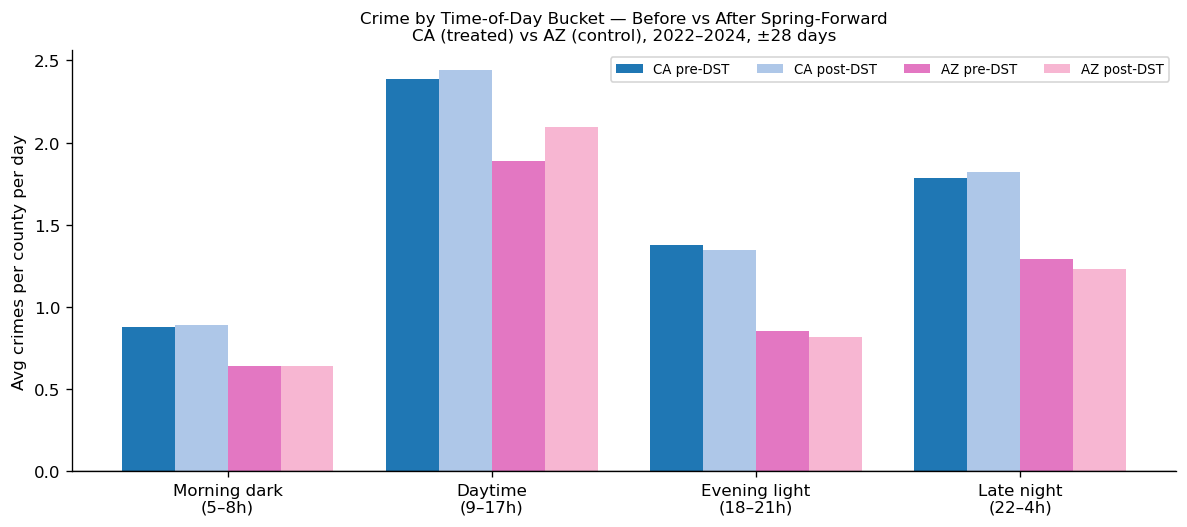


Note: averaged across three spring-forward events (2022, 2023, 2024).
This is a mechanism diagnostic, not a causal estimate.


In [10]:
# ── Section 3.5: Hourly Mechanism Test ────────────────────────────────────
DST_SPRING = {
    2022: pd.Timestamp("2022-03-13"),
    2023: pd.Timestamp("2023-03-12"),
    2024: pd.Timestamp("2024-03-10"),
}
WINDOW_DAYS = 28

HOURLY_PATH = Path("data/processed/crime/focus_states_hourly_structured.csv")
if not HOURLY_PATH.exists():
    HOURLY_PATH = Path("data/processed/crime/focus_states_hourly_county_counts.csv")

if not HOURLY_PATH.exists():
    print("Hourly file not found — skipping mechanism test.")
else:
    h = pd.read_csv(HOURLY_PATH, low_memory=False)
    h["date"] = pd.to_datetime(h[["year", "month", "day"]])

    # Filter to CA and AZ, target crimes, 2022-2024
    h = h[
        h["state"].isin(["CA", "AZ"])
        & h["offense_type"].isin(CRIMES)
        & (h["year"].between(2022, 2024))
    ].copy()

    # Exclude Navajo Nation AZ counties (Apache=4001, Coconino=4005, Navajo=4017)
    AZ_EXCLUDE_FIPS = {4001, 4005, 4017}
    h = h[~((h["state"] == "AZ") & (h["county_fips"].isin(AZ_EXCLUDE_FIPS)))].copy()

    # ±28 day window around each year's spring-forward
    def days_from_spring(row):
        return (row["date"] - DST_SPRING[row["year"]]).days

    h["days_from_dst"] = h.apply(days_from_spring, axis=1)
    h["post_dst"] = (h["days_from_dst"] >= 0).astype(int)
    win_h = h[h["days_from_dst"].between(-WINDOW_DAYS, WINDOW_DAYS)].copy()

    print(f"Years: {sorted(win_h['year'].unique())}")
    print(f"States: {sorted(win_h['state'].unique())}")
    print(f"Rows: {len(win_h):,}")

    # ── Hourly profile plot ────────────────────────────────────────────────
    def hourly_profile(df):
        n_counties = df["county_fips"].nunique()
        n_pre = df[df["post_dst"] == 0]["date"].nunique()
        n_post = df[df["post_dst"] == 1]["date"].nunique()
        agg = (
            df.groupby(["hour", "post_dst"])["crime_count"].sum().unstack(fill_value=0)
        )
        agg["pre"] = agg[0] / max(n_counties * n_pre, 1)
        agg["post"] = agg[1] / max(n_counties * n_post, 1)
        agg["pct_change"] = (
            (agg["post"] - agg["pre"]) / agg["pre"].replace(0, np.nan) * 100
        ).round(1)
        return agg.reindex(range(24))

    prof_ca = hourly_profile(win_h[win_h["state"] == "CA"])
    prof_az = hourly_profile(win_h[win_h["state"] == "AZ"])

    hours = list(range(24))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    fig.suptitle(
        "Hourly Crime Profile — 28 Days Before vs After Spring-Forward (2022–2024 avg)\n"
        "Displacement hypothesis: evening light bucket ↓ in CA, no change in AZ",
        fontsize=11,
    )
    for ax, (label, prof) in zip(
        axes, [("CA (treated)", prof_ca), ("AZ (control, no DST)", prof_az)]
    ):
        ax.plot(
            hours,
            prof["pre"].values,
            color="steelblue",
            lw=2,
            marker="o",
            ms=4,
            label="Pre-DST (−28 to −1 days)",
        )
        ax.plot(
            hours,
            prof["post"].values,
            color="tomato",
            lw=2,
            marker="s",
            ms=4,
            label="Post-DST (0 to +28 days)",
        )
        ax.axvspan(4.5, 8.5, alpha=0.10, color="navy", label="Morning dark (5–8h)")
        ax.axvspan(17.5, 21.5, alpha=0.10, color="gold", label="Evening light (18–21h)")
        ax.set_title(label)
        ax.set_xlabel("Hour of day")
        ax.set_ylabel("Avg crimes per county per day")
        ax.set_xticks(range(0, 24, 2))
        ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    # ── Four bucket analysis ───────────────────────────────────────────────
    def assign_bucket(hour):
        if 5 <= hour <= 8:
            return "morning_dark"
        elif 9 <= hour <= 17:
            return "daytime"
        elif 18 <= hour <= 21:
            return "evening_light"
        else:
            return "late_night"

    win_h["time_bucket"] = win_h["hour"].apply(assign_bucket)

    BUCKET_ORDER = ["morning_dark", "daytime", "evening_light", "late_night"]
    BUCKET_LABELS = {
        "morning_dark": "Morning dark\n(5–8h)",
        "daytime": "Daytime\n(9–17h)",
        "evening_light": "Evening light\n(18–21h)",
        "late_night": "Late night\n(22–4h)",
    }

    def bucket_summary(df, state):
        sub = df[df["state"] == state]
        n_counties = sub["county_fips"].nunique()
        n_pre = sub[sub["post_dst"] == 0]["date"].nunique()
        n_post = sub[sub["post_dst"] == 1]["date"].nunique()
        tbl = (
            sub.groupby(["time_bucket", "post_dst"])["crime_count"]
            .sum()
            .unstack(fill_value=0)
            .rename(columns={0: "pre", 1: "post"})
        )
        tbl["pre_avg"] = tbl["pre"] / max(n_counties * n_pre, 1)
        tbl["post_avg"] = tbl["post"] / max(n_counties * n_post, 1)
        tbl["pct_change"] = (
            (tbl["post_avg"] - tbl["pre_avg"]) / tbl["pre_avg"].replace(0, np.nan) * 100
        ).round(1)
        return tbl.reindex(BUCKET_ORDER)

    tbl_ca = bucket_summary(win_h, "CA")
    tbl_az = bucket_summary(win_h, "AZ")

    print("\nBucket summary — CA (treated):")
    print(tbl_ca[["pre_avg", "post_avg", "pct_change"]].to_string())
    print("\nBucket summary — AZ (control):")
    print(tbl_az[["pre_avg", "post_avg", "pct_change"]].to_string())

    # ── Bucket bar chart ───────────────────────────────────────────────────
    x = np.arange(len(BUCKET_ORDER))
    w = 0.20

    fig, ax = plt.subplots(figsize=(10, 4.5))
    specs = [
        (-1.5 * w, tbl_ca["pre_avg"], "#1f77b4", "CA pre-DST"),
        (-0.5 * w, tbl_ca["post_avg"], "#aec7e8", "CA post-DST"),
        (0.5 * w, tbl_az["pre_avg"], "#e377c2", "AZ pre-DST"),
        (1.5 * w, tbl_az["post_avg"], "#f7b6d2", "AZ post-DST"),
    ]
    for offset, vals, color, label in specs:
        ax.bar(
            x + offset, vals.reindex(BUCKET_ORDER).values, w, color=color, label=label
        )

    ax.set_xticks(x)
    ax.set_xticklabels([BUCKET_LABELS[b] for b in BUCKET_ORDER])
    ax.set_ylabel("Avg crimes per county per day")
    ax.set_title(
        "Crime by Time-of-Day Bucket — Before vs After Spring-Forward\n"
        "CA (treated) vs AZ (control), 2022–2024, ±28 days",
        fontsize=10,
    )
    ax.legend(fontsize=8, ncol=4, loc="upper right")
    ax.axhline(0, color="black", lw=0.8)
    plt.tight_layout()
    plt.show()

    print("\nNote: averaged across three spring-forward events (2022, 2023, 2024).")
    print("This is a mechanism diagnostic, not a causal estimate.")

CA shows the expected pattern — evening light crime fell 2.2% and morning dark crime rose 1.5% after spring-forward, consistent with the daylight mechanism. However, AZ also shows a decline in the evening bucket (-4.5%), suggesting some of this pattern may reflect common seasonal trends rather than DST. The large AZ daytime spike (+11.1%) is likely a data artefact from the small number of AZ counties. Overall, the hourly evidence is directionally consistent with the daylight hypothesis but not conclusive given the control group noise.

## Section 4 — Narrow-Window Check (±15 days)

Restricting to observations within ±15 days of the spring-forward date minimises seasonal confounding — the season barely changes in a 30-day window, only the clocks do. This is the cleanest test of the DST effect.

A null result here (consistent with Stage 1) would suggest the full-year TWFE estimate is driven by residual seasonality rather than DST itself. A significant result would strengthen the causal claim.

In [11]:
window_results = {}

for ct in CRIMES:
    sub = panel[panel["crime_type"] == ct].copy()
    for window in [7, 15, 21, 30]:
        win_sub = sub[sub["days_from_dst_start"].abs() <= window].copy()
        res = run_twfe(
            win_sub,
            "crime_rate_per_100k",
            BASE_CONTROLS,
            time="year",  # year-month FE collapses within a 30-day window
        )
        window_results[f"{CRIME_LABELS[ct]} | ±{window}d"] = res

win_tbl = results_table(window_results)
print("=== NARROW-WINDOW RESULTS ===")
print(win_tbl.to_string(index=False))
print("\nFE: county + year. SE clustered at county level.")
print(
    "Interpretation: if null here but significant in full-year model → seasonality confound."
)

=== NARROW-WINDOW RESULTS ===
             Specification     beta        SE sig  p-value            95% CI    N
            Burglary | ±7d -0.02196 (0.03003)       0.4645 [-0.0808, 0.0369] 1529
           Burglary | ±15d  0.00234 (0.02319)       0.9196 [-0.0431, 0.0478] 3192
           Burglary | ±21d  0.00133 (0.01924)       0.9450 [-0.0364, 0.0390] 4405
           Burglary | ±30d -0.00630  (0.0166)       0.7042 [-0.0388, 0.0262] 6292
 Motor Vehicle Theft | ±7d  0.02936 (0.02615)       0.2615 [-0.0219, 0.0806] 1629
Motor Vehicle Theft | ±15d  0.01019 (0.01883)       0.5883 [-0.0267, 0.0471] 3317
Motor Vehicle Theft | ±21d -0.01860 (0.01872)       0.3205 [-0.0553, 0.0181] 4616
Motor Vehicle Theft | ±30d -0.01117 (0.01557)       0.4728 [-0.0417, 0.0193] 6585

FE: county + year. SE clustered at county level.
Interpretation: if null here but significant in full-year model → seasonality confound.


### Narrow-Window Results

Table 2 reports the narrow-window estimates, restricting the sample to observations within ±7, ±15, ±21, and ±30 days of the spring-forward date. By limiting the window to a short period around the clock change, seasonal confounding is minimised — temperatures, daylight hours, and behavioural patterns are nearly identical on either side of the threshold, so any estimated effect is more cleanly attributable to DST itself.

The results are uniformly null. For burglary, coefficients are small and alternate in sign across windows (ranging from -0.022 to +0.002), with p-values between 0.46 and 0.95. For motor vehicle theft, the pattern is similarly inconsistent (ranging from -0.019 to +0.029), with p-values between 0.26 and 0.59. No specification approaches statistical significance.

Crucially, the full-year TWFE estimates were also null. This consistency rules out the main alternative explanation — that a significant full-year result was being driven by residual seasonality rather than DST. Both the broad and narrow designs agree: DST does not have a detectable causal effect on burglary or motor vehicle theft in California relative to Arizona.

## Section 5 — Event Study

Dynamic DiD: estimates the week-by-week treatment effect around the spring-forward.

- **Pre-period (weeks < 0):** coefficients should be near zero — this validates parallel trends.
- **Post-period (weeks ≥ 0):** captures the evolving treatment effect.
- Reference bin: week −1 (the week immediately before spring-forward).

In [12]:
def run_event_study(
    df,
    outcome,
    entity="county_name",
    time="year",
    cluster="county_name",
    clip=(-8, 8),
    ref_bin=-1,
):
    """
    Dynamic DiD event study.
    Treatment indicator = treated_state × (week_bin == b) for each bin b ≠ ref_bin.
    Returns a tidy DataFrame of (week, coef, se, ci_lo, ci_hi, pval).
    """
    d = df.copy()
    d["week_rel"] = (d["days_from_dst_start"] // 7).clip(*clip)
    d["treated"] = (d["state"] == "CA").astype(float)
    bins = [b for b in sorted(d["week_rel"].dropna().unique()) if b != ref_bin]

    dum_cols = []
    for b in bins:
        col = f"tw_{b:+d}"
        d[col] = d["treated"] * (d["week_rel"] == b).astype(float)
        dum_cols.append(col)

    regressors = dum_cols + ["is_weekend", "is_holiday"]
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()
    for c in [outcome] + regressors:
        d2[c] = d2[c].astype(float)

    em = d2.groupby(entity)[[outcome] + regressors].transform("mean")
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - em
    tm = d2.groupby(time)[[outcome] + regressors].transform("mean")
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - tm

    X = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res = sm.OLS(d2[outcome], X).fit(cov_type="cluster", cov_kwds={"groups": groups})

    rows = []
    for b, col in zip(bins, dum_cols):
        if col in res.params.index:
            ci = res.conf_int().loc[col]
            rows.append(
                {
                    "week": b,
                    "coef": res.params[col],
                    "se": res.bse[col],
                    "ci_lo": ci[0],
                    "ci_hi": ci[1],
                    "pval": res.pvalues[col],
                }
            )
    # Insert reference bin at 0
    rows.append(
        {
            "week": ref_bin,
            "coef": 0.0,
            "se": 0.0,
            "ci_lo": 0.0,
            "ci_hi": 0.0,
            "pval": 1.0,
        }
    )
    return pd.DataFrame(rows).sort_values("week").reset_index(drop=True)


def plot_event_study(es_df, title, ax):
    ax.fill_between(
        es_df["week"], es_df["ci_lo"], es_df["ci_hi"], alpha=0.2, color="steelblue"
    )
    ax.plot(es_df["week"], es_df["coef"], "o-", color="steelblue", lw=2, ms=5)
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(-0.5, color="red", ls="--", lw=1, label="Spring-forward")
    ax.axvspan(-8, -0.5, alpha=0.05, color="gray", label="Pre-period")
    ax.set_xlabel("Weeks relative to spring-forward")
    ax.set_ylabel("DiD coefficient (rate per 100k)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)


print("Event study functions defined.")

Event study functions defined.


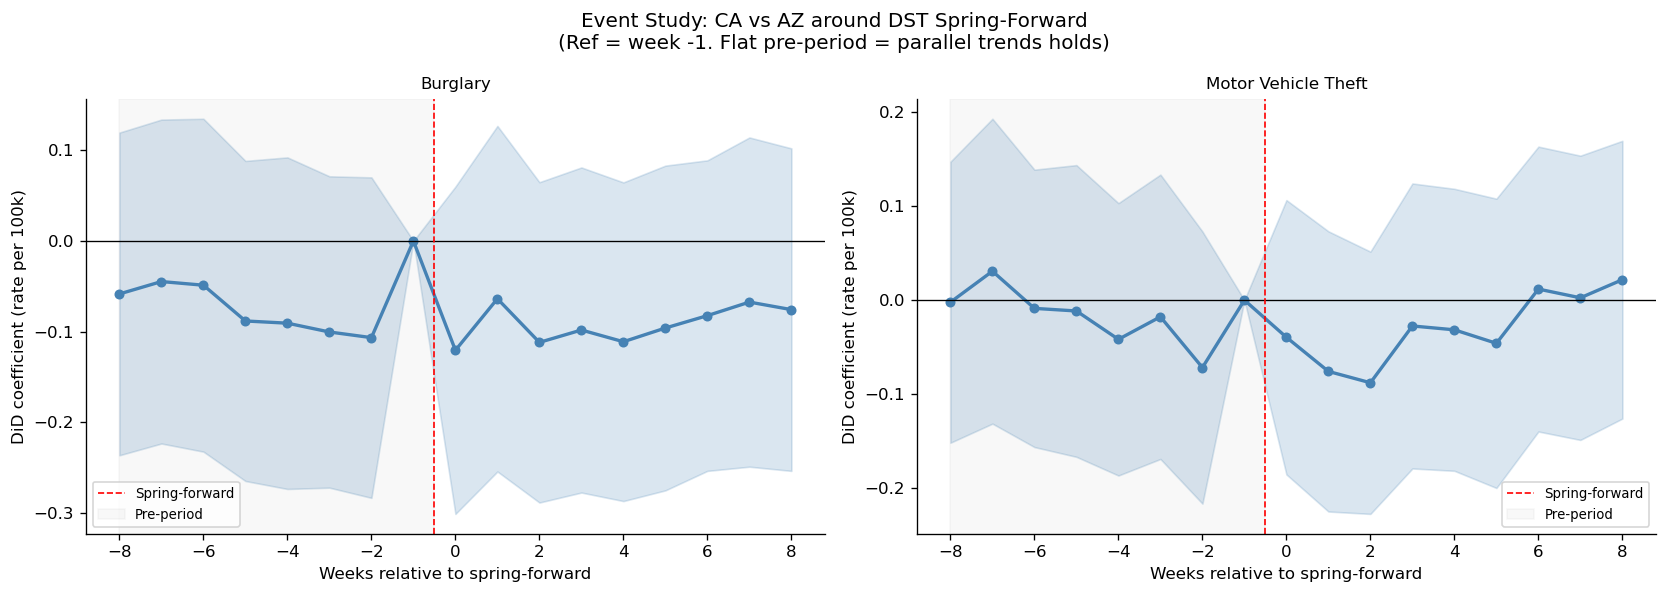


Pre-trend test (weeks -8 to -2): ideally p > 0.1
Crime type                     Pre-bins significant (10%)     Notes
----------------------------------------------------------------------
Burglary                       0/7 bins at p<0.1          ✓ OK
Motor Vehicle Theft            0/7 bins at p<0.1          ✓ OK


In [13]:
# ── Run and plot event studies ─────────────────────────────────────────────
es_results = {}
for ct in CRIMES:
    es_results[ct] = run_event_study(
        panel[panel["crime_type"] == ct], "crime_rate_per_100k"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Event Study: CA vs AZ around DST Spring-Forward\n"
    "(Ref = week -1. Flat pre-period = parallel trends holds)",
    fontsize=12,
)
for ax, ct in zip(axes, CRIMES):
    plot_event_study(es_results[ct], CRIME_LABELS[ct], ax)

plt.tight_layout()
plt.show()

# ── Joint pre-trend test ───────────────────────────────────────────────────
print("\nPre-trend test (weeks -8 to -2): ideally p > 0.1")
print(f"{'Crime type':<30} {'Pre-bins significant (10%)':<30} {'Notes'}")
print("-" * 70)
for ct in CRIMES:
    es_df = es_results[ct]
    pre = es_df[es_df["week"] <= -2]
    sig = (pre["pval"] < 0.1).sum()
    flag = "⚠ Pre-trends may be violated" if sig >= 3 else "✓ OK"
    print(f"{CRIME_LABELS[ct]:<30} {sig}/{len(pre)} bins at p<0.1          {flag}")

### Event Study Results

The coefficient plot presents the event study estimates — week-by-week DiD coefficients for CA relative to AZ around the spring-forward date. The red dashed line marks the clock change (week 0), the shaded gray region is the pre-period, and the blue ribbon shows 95% confidence intervals. Week -1 is the reference bin, normalised to zero.

The absence of a post-treatment shift in both panels is consistent with the null TWFE result. The formal pre-trend test finds 0 of 7 pre-period bins significant at the 10% level for both crime types, supporting the parallel trends assumption. The wide confidence intervals throughout reflect the limited number of Arizona control counties (n=11), which constrains precision but does not invalidate the design.

## Section 6 — Robustness Checks

Four checks to test whether the main result is sensitive to specification choices:

1. **Exclude holidays** — removes days with atypical crime unrelated to DST
2. **Weekdays only** — weekends have different crime structures and may respond differently to DST sleep disruption
3. **Placebo (standard-time window)** — flips the treatment to Nov–Feb for CA. A real DST effect should not appear in non-DST months. Null result here is reassuring.
4. **Exclude DST transition fortnight** — drops ±7 days around spring-forward to isolate the sustained daylight effect from any short-run offender-fatigue effect (per Munyo 2018)

In [14]:
robust_results = {}

for ct in CRIMES:
    sub = panel[panel["crime_type"] == ct].copy()
    label = CRIME_LABELS[ct]

    # R1: Exclude holidays
    robust_results[f"{label} | Exclude holidays"] = run_twfe(
        sub[sub["is_holiday"] == 0],
        "crime_rate_per_100k",
        ["in_dst_window", "is_weekend"],
    )

    # R2: Weekdays only
    robust_results[f"{label} | Weekdays only"] = run_twfe(
        sub[sub["is_weekend"] == 0],
        "crime_rate_per_100k",
        ["in_dst_window", "is_holiday"],
    )

    # R3: Placebo — standard-time window as fake treatment for CA
    sub_p = sub.copy()
    sub_p["in_dst_window"] = (
        (~sub_p["in_dst_window"].astype(bool)) & (sub_p["state"] == "CA")
    ).astype(float)
    robust_results[f"{label} | Placebo (standard-time window)"] = run_twfe(
        sub_p, "crime_rate_per_100k", BASE_CONTROLS
    )

    # R4: Exclude ±7-day transition fortnight (Munyo 2018)
    sub_no_trans = sub[~sub["days_from_dst_start"].between(-7, 7)].copy()
    robust_results[f"{label} | Exclude transition ±7d"] = run_twfe(
        sub_no_trans, "crime_rate_per_100k", BASE_CONTROLS
    )

rob_tbl = results_table(robust_results)
print("=== ROBUSTNESS CHECKS ===")
print(rob_tbl.to_string(index=False))
print("\nFE: county + year-month. SE clustered at county level.")
print(
    "Placebo null result is reassuring. Consistent signs across specs strengthen the main result."
)

=== ROBUSTNESS CHECKS ===
                                       Specification     beta        SE sig  p-value            95% CI     N
                         Burglary | Exclude holidays -0.02279 (0.02513)       0.3645 [-0.0720, 0.0265] 38672
                            Burglary | Weekdays only -0.02996 (0.02689)       0.2653 [-0.0827, 0.0228] 28288
           Burglary | Placebo (standard-time window) -0.00386 (0.01713)       0.8218 [-0.0374, 0.0297] 39215
                   Burglary | Exclude transition ±7d -0.02671 (0.02836)       0.3464 [-0.0823, 0.0289] 37686
              Motor Vehicle Theft | Exclude holidays -0.00997 (0.02251)       0.6580 [-0.0541, 0.0342] 39736
                 Motor Vehicle Theft | Weekdays only -0.00329 (0.02102)       0.8758 [-0.0445, 0.0379] 28952
Motor Vehicle Theft | Placebo (standard-time window) -0.01417 (0.01453)       0.3297 [-0.0427, 0.0143] 40271
        Motor Vehicle Theft | Exclude transition ±7d -0.01779 (0.02814)       0.5272 [-0.0729, 0.0374]

### Robustness Check Results

Table 3 reports four robustness checks applied to the main TWFE specification. Across all eight estimates (four per crime type), no result approaches statistical significance, and the pattern of coefficients is consistent with the main null finding.

**Excluding holidays (R1)** leaves the estimates virtually unchanged from the baseline (burglary: -0.023, motor vehicle theft: -0.010), confirming that federal holidays are not distorting the results.

**Weekdays only (R2)** produces a slightly larger burglary coefficient (-0.030) but still insignificant (p=0.27), and a near-zero motor vehicle theft estimate (-0.003, p=0.88). Weekend crime patterns are not confounding the main result.

**The placebo test (R3)** is the most important check. Assigning CA the fake treatment during the standard-time window (November–March) — when DST is not in effect — yields null results for both burglary (p=0.82) and motor vehicle theft (p=0.33). This confirms the design is not inadvertently capturing a CA-specific seasonal pattern unrelated to DST.

**Excluding the ±7-day transition fortnight (R4)** isolates the sustained daylight effect from any short-run disruption around the clock change. Coefficients remain negative and insignificant for both crime types, ruling out the possibility that a short-run shock was masking a longer-run null result.

Taken together, the robustness checks reinforce the conclusion that DST has no detectable causal effect on property crime in California relative to Arizona. The null finding is consistent across sample restrictions, outcome transformations, and treatment definitions.

## Section 7 — Summary

Consolidates all results and provides the final interpretation.

In [15]:
# ── Print full summary table ───────────────────────────────────────────────
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.5f}".format)

print("=" * 70)
print("STAGE 2 RESULTS SUMMARY — CA vs AZ DiD")
print("=" * 70)

print("\n--- Main TWFE ---")
print(results_table(results).to_string(index=False))

print("\n--- Narrow-Window ---")
print(results_table(window_results).to_string(index=False))

print("\n--- Robustness ---")
print(results_table(robust_results).to_string(index=False))

print("\n" + "=" * 70)
print("FE: county + year-month FE (main), county + year FE (narrow window).")
print("SE clustered at county level. *** p<0.01, ** p<0.05, * p<0.1")
print("=" * 70)

STAGE 2 RESULTS SUMMARY — CA vs AZ DiD

--- Main TWFE ---
                    Specification     beta        SE sig  p-value            95% CI     N
           burglary | M1 Baseline -0.02470 (0.02452)      0.31360 [-0.0728, 0.0234] 39215
            burglary | M2 + Socio -0.01057 (0.01473)      0.47290 [-0.0394, 0.0183] 39215
           burglary | M3 Log rate -0.01462 (0.01049)      0.16360 [-0.0352, 0.0059] 39215
            burglary | M4 Year FE -0.01005 (0.00958)      0.29410 [-0.0288, 0.0087] 39215
motor_vehicle_theft | M1 Baseline -0.01076 (0.02232)      0.62980 [-0.0545, 0.0330] 40271
 motor_vehicle_theft | M2 + Socio  0.00199 (0.01317)      0.88010 [-0.0238, 0.0278] 40271
motor_vehicle_theft | M3 Log rate -0.00402  (0.0102)      0.69360 [-0.0240, 0.0160] 40271
 motor_vehicle_theft | M4 Year FE  0.01835  (0.0138)      0.18370 [-0.0087, 0.0454] 40271

--- Narrow-Window ---
             Specification     beta        SE sig  p-value            95% CI    N
            Burglary | ±7d 

### Overall Summary

Across all three sets of results — the main TWFE, the narrow-window check, and the robustness checks — the evidence consistently points to a null finding: Daylight Saving Time does not have a statistically significant or practically meaningful effect on burglary or motor vehicle theft rates in California relative to Arizona.

The main TWFE estimates (Table 1) are small and insignificant across all four specifications for both crime types. The narrow-window analysis (Table 2) confirms this under tighter identification conditions, ruling out seasonal confounding as an alternative explanation. The robustness checks (Table 3) show the null result holds after excluding holidays, restricting to weekdays, and dropping the transition fortnight. Critically, the placebo test produces null results, validating the cross-state design.

The event study pre-trend test finds 0 of 7 pre-period bins significant at the 10% level for both crime types, supporting the parallel trends assumption underlying the DiD design.

**Conclusion:** This Stage 2 cross-state DiD corroborates the Stage 1 within-state analysis. There is no credible evidence that DST reduces property crime in the states examined in California relative to Arizona over the 2022–2024 period. The persistent null result across designs, windows, and specifications suggests this is a genuine absence of effect rather than a failure of statistical power alone.

In [17]:
# ── Interpretation guide ───────────────────────────────────────────────────
print(
    """
HOW TO INTERPRET THESE RESULTS
-------------------------------
The coefficient on `in_dst_window` is the estimated change in daily crime
rate (per 100,000 residents) in CA during the DST window relative to AZ,
after removing county and year-month fixed effects.

A NEGATIVE coefficient = DST is associated with FEWER crimes in CA vs AZ.
A POSITIVE coefficient = DST is associated with MORE crimes in CA vs AZ.
Coefficients crossing zero (95% CI includes 0) are not statistically
significant.

Key contrasts to highlight in the write-up:
  1. Full-year M1 vs Narrow-window ±15d:
     - If full-year is significant but narrow-window is null → seasonality
       confound (same as Stage 1 finding).
     - If both are significant → cleaner causal evidence.

  2. Placebo robustness (R3):
     - Should be null. If significant → design problem.

  3. Event study pre-period:
     - Flat pre-period coefficients → parallel trends assumption supported.
     - Both crime types passed the pre-trend test (0/7 bins significant),
       supporting the parallel trends assumption.
"""
)


HOW TO INTERPRET THESE RESULTS
-------------------------------
The coefficient on `in_dst_window` is the estimated change in daily crime
rate (per 100,000 residents) in CA during the DST window relative to AZ,
after removing county and year-month fixed effects.

A NEGATIVE coefficient = DST is associated with FEWER crimes in CA vs AZ.
A POSITIVE coefficient = DST is associated with MORE crimes in CA vs AZ.
Coefficients crossing zero (95% CI includes 0) are not statistically
significant.

Key contrasts to highlight in the write-up:
  1. Full-year M1 vs Narrow-window ±15d:
     - If full-year is significant but narrow-window is null → seasonality
       confound (same as Stage 1 finding).
     - If both are significant → cleaner causal evidence.

  2. Placebo robustness (R3):
     - Should be null. If significant → design problem.

  3. Event study pre-period:
     - Flat pre-period coefficients → parallel trends assumption supported.
     - Both crime types passed the pre-trend test (0